# Hiring Decision Analysis

Due to the small scale of this exercise, all steps including EDA, model building, and evaluation are performed in this single notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## EDA

In [2]:
data = pd.read_csv(r'C:\Users\Island\OneDrive\Desktop\ML Projects\ml-practice-lab\2- small-data-hiring-analysis\datasets\data.csv')
data

,Experience,Education,Skill_Match,Communication,Result
0,Senior,Bachelor,High,Weak,0
1,Junior,Master,High,Weak,0
2,Senior,Bachelor,High,Weak,0
3,Senior,Master,High,Strong,1
4,Junior,Master,Low,Strong,0
...,...,...,...,...,...
195,Mid,Master,Low,Weak,0
196,Senior,Master,High,Weak,0
197,Senior,PhD,High,Weak,0
198,Mid,PhD,Low,Strong,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Experience     200 non-null    str  
 1   Education      200 non-null    str  
 2   Skill_Match    200 non-null    str  
 3   Communication  200 non-null    str  
 4   Result         200 non-null    int64
dtypes: int64(1), str(4)
memory usage: 7.9 KB


In [4]:
data['Result'].value_counts()

Result
0    140
1     60
Name: count, dtype: int64

<Axes: xlabel='Result', ylabel='count'>

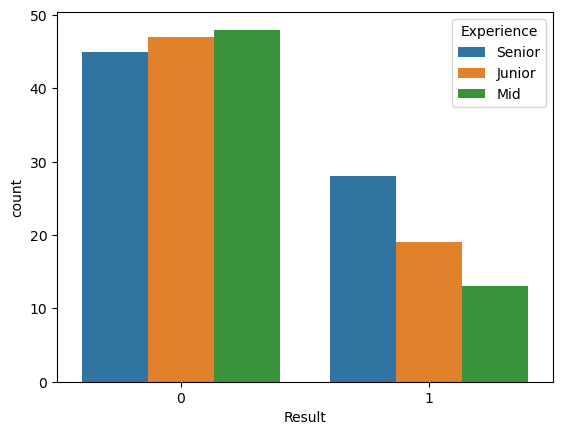

In [5]:
sns.countplot(data, x='Result', hue='Experience')

<Axes: xlabel='Result', ylabel='count'>

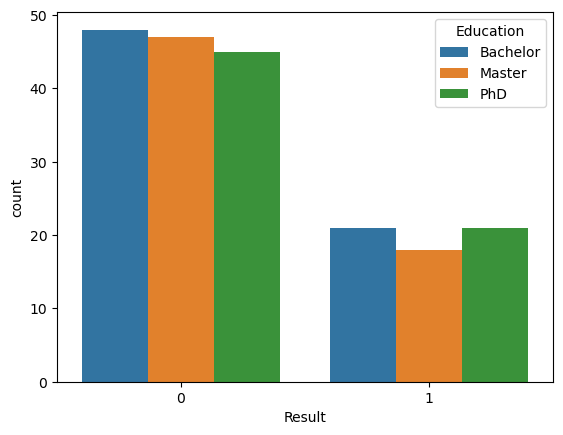

In [6]:
sns.countplot(data, x='Result', hue='Education')

<Axes: xlabel='Result', ylabel='count'>

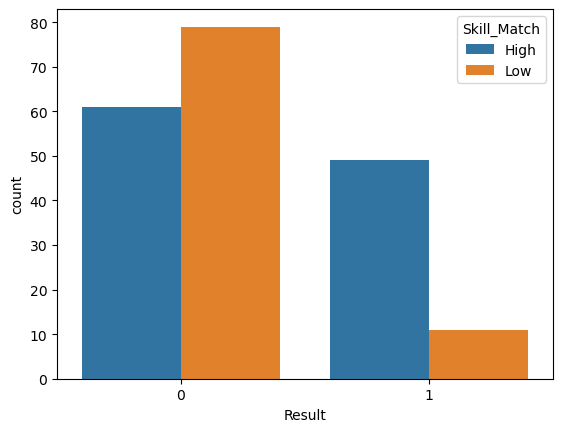

In [7]:
sns.countplot(data, x='Result', hue='Skill_Match')

<Axes: xlabel='Result', ylabel='count'>

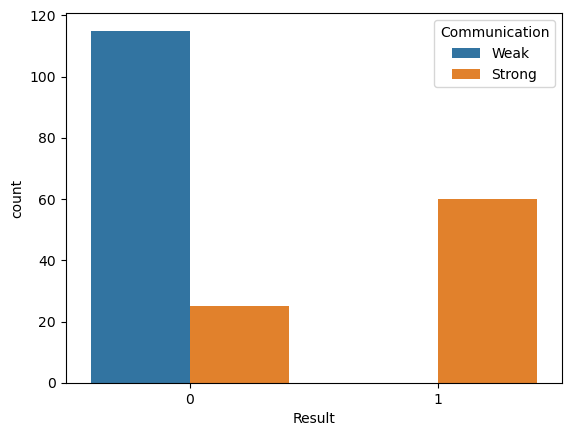

In [8]:
sns.countplot(data, x='Result', hue='Communication')

EDA for preparing data

In [9]:
data.nunique()

Experience       3
Education        3
Skill_Match      2
Communication    2
Result           2
dtype: int64

## prepare and format the data for model training

In [10]:
x = data.drop('Result', axis=1)
y = data['Result']

In [11]:
ohe = sklearn.preprocessing.OneHotEncoder(drop='first')
le = sklearn.preprocessing.LabelEncoder()

In [12]:
x_preprocessed = ohe.fit_transform(x)
y_preprocessed = le.fit_transform(y)

In [13]:
y_preprocessed

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0])

In [14]:
x_preprocessed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 470 stored elements and shape (200, 6)>

## Train and Evaluate the Classification Models

In [15]:
lr = sklearn.linear_model.LogisticRegression()
dt = sklearn.tree.DecisionTreeClassifier()
cv = sklearn.model_selection.cross_val_score

In [19]:
lr_accuracies = cv(lr, x_preprocessed, y_preprocessed, scoring='accuracy', cv=10)
dt_accuracies = cv(dt, x_preprocessed, y_preprocessed, scoring='accuracy', cv=10)

In [20]:
lr_accuracies

array([1.  , 1.  , 1.  , 1.  , 0.95, 1.  , 1.  , 1.  , 1.  , 0.9 ])

In [21]:
dt_accuracies

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])